In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
crime_df = pd.read_csv('crime_data.csv')
socio_df = pd.read_csv('socioeconomic_data.csv')

In [3]:
# Merge yearly crime records with state socioeconomic indicators
df = pd.merge(crime_df, socio_df, on=['State', 'Region'], how='inner')

In [5]:
# Digital crime metrics i.e cybercrime + frauds
df['Digital_Crimes'] = df['Cybercrime'] + df['Fraud']

In [7]:
# Proportion of Digital crimes compared to Total crimes
df['Digital_Crime_Share_%']= (df['Digital_Crimes']/df['Total_Crimes'])*100

In [8]:
# Proportion of Violent Crimes relative to Total Crimes
df['Violent_Crime_Share_%'] = (df['Violent_Crimes'] / df['Total_Crimes']) * 100

In [9]:
# Income Tiers using Pandas Quantile Binning
df['Income_Tier'] = pd.qcut(
    df['GDP_per_Capita_INR'], 
    q=3, 
    labels=['Low Income', 'Medium Income', 'High Income']
)

In [10]:
# Correlation test between Urbanization and Digital Crime Share
state_summary = df.groupby('State').agg({
    'Urbanization_%': 'first',
    'Literacy_Rate_%': 'first',
    'Unemployment_Rate_%': 'first',
    'GDP_per_Capita_INR': 'first',
    'Crime_Rate_per_100k': 'mean',
    'Digital_Crime_Share_%': 'mean'
}).reset_index()

In [11]:
corr, p_value = pearsonr(state_summary['Urbanization_%'], state_summary['Digital_Crime_Share_%'])
print(f"Urbanization vs Digital Crime Share Correlation: {corr:.3f} (p-value: {p_value:.4f})")

Urbanization vs Digital Crime Share Correlation: 0.100 (p-value: 0.5599)


C:\Users\ā\AppData\Local\Temp\ipykernel_4488\3489504992.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


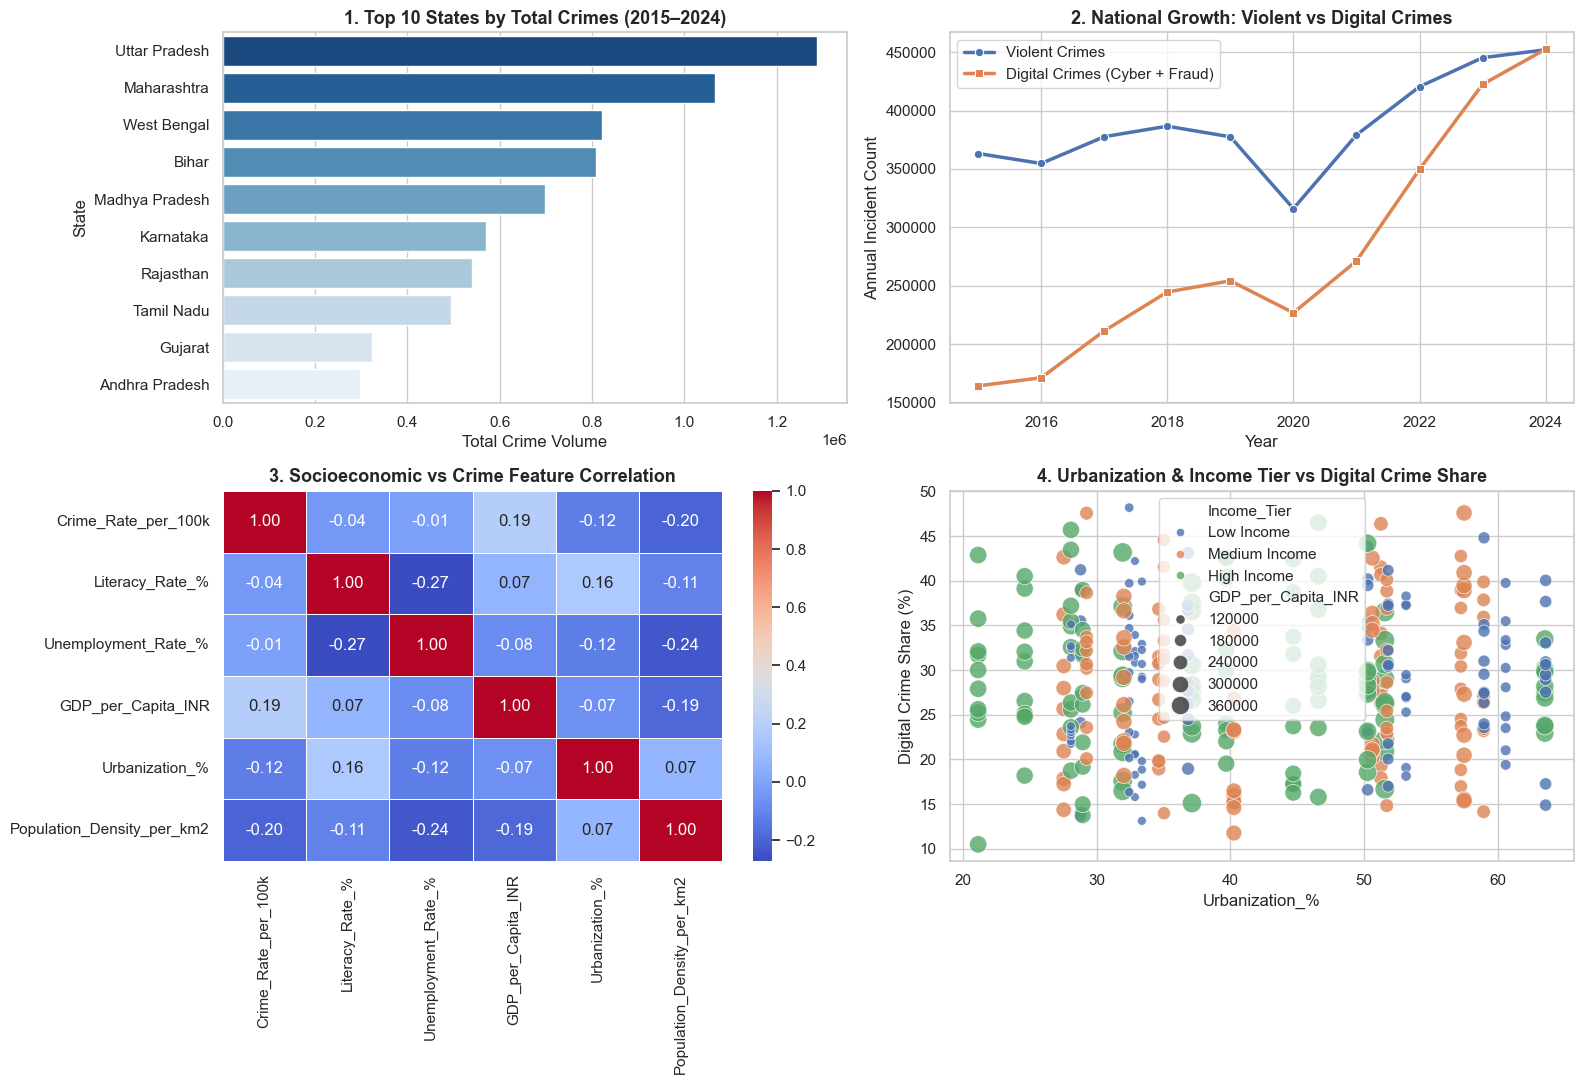

In [14]:
sns.set_theme(style="whitegrid", font_scale=1.0)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
# --- Plot 1: Top 10 States by Total Crime Volume ---
top10_states = df.groupby('State')['Total_Crimes'].sum().nlargest(10).reset_index()
sns.barplot(
    data=top10_states, 
    x='Total_Crimes', 
    y='State', 
    palette='Blues_r', 
    ax=axes[0, 0]
)
axes[0, 0].set_title('1. Top 10 States by Total Crimes (2015–2024)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Total Crime Volume')

# --- Plot 2: 10-Year Trajectory — Violent vs Digital Crimes ---
yearly_trends = df.groupby('Year')[['Violent_Crimes', 'Digital_Crimes']].sum().reset_index()
sns.lineplot(
    data=yearly_trends, x='Year', y='Violent_Crimes', 
    marker='o', linewidth=2.5, label='Violent Crimes', ax=axes[0, 1]
)
sns.lineplot(
    data=yearly_trends, x='Year', y='Digital_Crimes', 
    marker='s', linewidth=2.5, label='Digital Crimes (Cyber + Fraud)', ax=axes[0, 1]
)
axes[0, 1].set_title('2. National Growth: Violent vs Digital Crimes', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Annual Incident Count')

# --- Plot 3: Correlation Heatmap ---
corr_cols = [
    'Crime_Rate_per_100k', 'Literacy_Rate_%', 'Unemployment_Rate_%', 
    'GDP_per_Capita_INR', 'Urbanization_%', 'Population_Density_per_km2'
]
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1, 0])
axes[1, 0].set_title('3. Socioeconomic vs Crime Feature Correlation', fontsize=13, fontweight='bold')

# --- Plot 4: Scatter Plot (Urbanization vs Digital Share by Income Tier) ---
sns.scatterplot(
    data=df, 
    x='Urbanization_%', 
    y='Digital_Crime_Share_%', 
    hue='Income_Tier', 
    size='GDP_per_Capita_INR', 
    sizes=(40, 200), 
    alpha=0.8, 
    ax=axes[1, 1]
)
axes[1, 1].set_title('4. Urbanization & Income Tier vs Digital Crime Share', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Digital Crime Share (%)')

plt.tight_layout()
plt.show()